# Notebook 05: G-Computation for Long-Term Effects

Notebook 04 estimated the long-term effect of high-watch exposure using a marginal structural model. That approach modeled treatment assignment, created inverse probability weights, and then estimated the effect in a weighted pseudo-population.

This notebook estimates the same causal question using a different strategy: **g-computation**. Instead of modeling the probability of treatment, g-computation models the future outcome directly:

```text
future_7day_interactions ~ treatment + pre-treatment history + calendar context
```

Once the outcome model is fit, we simulate two counterfactual predictions for every user-day:

- predicted future engagement if the user-day were treated;
- predicted future engagement if the same user-day were untreated.

The average difference between those two predictions estimates:

```text
E[Y(1) - Y(0)]
```

This is a strong next step because it checks whether an outcome-modeling approach tells a similar story to the weighting approach from Notebook 04.


## Why G-Computation Helps This Project

A marginal structural model and g-computation make different modeling bets.

- The MSM relies heavily on the treatment model and the resulting inverse probability weights.
- G-computation relies heavily on the outcome model and its ability to predict future engagement under both treatment states.

Neither approach magically solves unobserved confounding. But if both approaches, using the same estimand and legal pre-treatment covariates, produce a similar answer, the project becomes more credible. If they disagree, that disagreement is informative and should be discussed as model sensitivity.


## Setup

The first cell imports the libraries used for outcome modeling, cross-fitting, diagnostics, bootstrap uncertainty, and plots. We use two outcome-model families: a regularized linear model for transparency and LightGBM for flexible nonlinear prediction.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from lightgbm import LGBMRegressor
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="X does not have valid feature names")

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42


The notebook environment is ready for outcome-model-based causal estimation. The important modeling choice is that the same pre-treatment feature set will be used for all models, so differences in estimates reflect model family rather than different covariate rules.


## Locate the Weighted Panel and MSM Result

This notebook uses the weighted panel from Notebook 03 because it already contains the final estimand population and standardized columns. It also loads the primary MSM result from Notebook 04 so the two causal strategies can be compared directly.


In [2]:
WEIGHTED_PANEL_RELATIVE_PATH = Path("data/processed/kuairec_long_term_weighted_panel.parquet")
MSM_PRIMARY_RELATIVE_PATH = Path("data/processed/kuairec_long_term_msm_primary_statement.csv")

candidate_roots = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(
    (path for path in candidate_roots if (path / WEIGHTED_PANEL_RELATIVE_PATH).exists()),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Could not find {WEIGHTED_PANEL_RELATIVE_PATH}. Run Notebook 03 first or run this notebook inside the project."
    )

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PANEL_PATH = PROJECT_ROOT / WEIGHTED_PANEL_RELATIVE_PATH
MSM_PRIMARY_PATH = PROJECT_ROOT / MSM_PRIMARY_RELATIVE_PATH

print(f"Project root: {PROJECT_ROOT}")
print(f"Weighted panel: {PANEL_PATH}")
print(f"MSM primary result: {MSM_PRIMARY_PATH}")
print(f"Processed output folder: {PROCESSED_DIR}")


Project root: /home/apex/Documents/ranking_sys
Weighted panel: /home/apex/Documents/ranking_sys/data/processed/kuairec_long_term_weighted_panel.parquet
MSM primary result: /home/apex/Documents/ranking_sys/data/processed/kuairec_long_term_msm_primary_statement.csv
Processed output folder: /home/apex/Documents/ranking_sys/data/processed


The notebook found both required inputs. The weighted panel supplies the analysis rows and covariates, while the MSM result provides the benchmark effect estimate from the previous notebook.


## Load the Analysis Panel

The primary treatment is `treatment`, and the primary outcome is `outcome`, which means future 7-day interaction volume. The panel also includes repeated user-days, so model evaluation and bootstrap uncertainty should respect `user_id` groups.


In [3]:
panel = pd.read_parquet(PANEL_PATH)
panel["event_date"] = pd.to_datetime(panel["event_date"])
panel = panel.sort_values(["user_id", "event_date"]).reset_index(drop=True)

PRIMARY_TREATMENT = "treatment"
PRIMARY_OUTCOME = "outcome"

required_columns = ["user_id", "event_date", "day_of_week", PRIMARY_TREATMENT, PRIMARY_OUTCOME]
missing_required = [column for column in required_columns if column not in panel.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

print(f"Panel shape: {panel.shape}")
print(f"Users: {panel['user_id'].nunique():,}")
print(f"Date range: {panel['event_date'].min().date()} to {panel['event_date'].max().date()}")
display(panel[required_columns + ["analysis_weight", "propensity_logistic"]].head())


Panel shape: (4698, 40)
Users: 91
Date range: 2020-07-08 to 2020-08-29


,user_id,event_date,day_of_week,treatment,outcome,analysis_weight,propensity_logistic
0,14,2020-07-08,Wednesday,1,279.0000,0.9131,0.5471
1,14,2020-07-09,Thursday,0,311.0000,1.3647,0.6333
2,14,2020-07-10,Friday,1,352.0000,1.2067,0.4140
3,14,2020-07-11,Saturday,1,437.0000,0.8836,0.5654
4,14,2020-07-12,Sunday,0,437.0000,1.2466,0.5986


The loaded table is the same final estimand population used by the MSM notebook. Because the treatment and outcome columns are standardized, this notebook can focus on the g-computation strategy rather than redefining the causal question.


## Define the Outcome-Model Features

G-computation needs an outcome model that uses the treatment and pre-treatment covariates. The treatment is included because we want to estimate how predicted outcomes change when the treatment is toggled. The history and calendar features are included to adjust for observed confounding.

No future outcome columns are included as features.


In [4]:
base_numeric_covariates = [
    "lag_1_active_day",
    "lag_1_interactions",
    "lag_1_total_play_duration_sec",
    "lag_1_avg_watch_ratio",
    "lag_1_high_watch_share",
    "prior_3day_active_day",
    "prior_3day_interactions",
    "prior_3day_total_play_duration_sec",
    "prior_3day_avg_watch_ratio",
    "prior_3day_high_watch_share",
    "calendar_day_index",
    "panel_day_index",
]

numeric_features = [PRIMARY_TREATMENT] + base_numeric_covariates
categorical_features = ["day_of_week"]
outcome_features = numeric_features + categorical_features

feature_table = pd.DataFrame(
    [
        {"role": "treatment toggle", "columns": PRIMARY_TREATMENT, "reason": "Set to 1 and 0 to generate counterfactual predictions."},
        {"role": "pre-treatment numeric history", "columns": ", ".join(base_numeric_covariates), "reason": "Adjust for recent activity and watch behavior."},
        {"role": "calendar context", "columns": ", ".join(categorical_features), "reason": "Account for day-of-week patterns in engagement."},
    ]
)

display(feature_table)


,role,columns,reason
0,treatment toggle,treatment,Set to 1 and 0 to generate counterfactual pred...
1,pre-treatment numeric history,"lag_1_active_day, lag_1_interactions, lag_1_to...",Adjust for recent activity and watch behavior.
2,calendar context,day_of_week,Account for day-of-week patterns in engagement.


The feature set respects the causal timing: it uses treatment and pre-treatment context, but not future information. This lets the outcome model simulate counterfactual treatment states for the same user-day history.


## Outcome and Treatment Summary

Before fitting outcome models, we summarize the treatment split and outcome distribution. This gives a baseline sense of how hard the prediction problem is and how much variation exists in future engagement.


In [5]:
outcome_summary = pd.DataFrame(
    [
        {"metric": "rows", "value": len(panel)},
        {"metric": "users", "value": panel["user_id"].nunique()},
        {"metric": "treatment_rate", "value": panel[PRIMARY_TREATMENT].mean()},
        {"metric": "outcome_mean", "value": panel[PRIMARY_OUTCOME].mean()},
        {"metric": "outcome_std", "value": panel[PRIMARY_OUTCOME].std()},
        {"metric": "outcome_min", "value": panel[PRIMARY_OUTCOME].min()},
        {"metric": "outcome_median", "value": panel[PRIMARY_OUTCOME].median()},
        {"metric": "outcome_max", "value": panel[PRIMARY_OUTCOME].max()},
    ]
)

display(outcome_summary)

display(
    panel.groupby(PRIMARY_TREATMENT)[PRIMARY_OUTCOME]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .rename_axis("treatment")
)


,metric,value
0,rows,"4,698.0000"
1,users,91.0000
2,treatment_rate,0.4996
3,outcome_mean,382.0826
4,outcome_std,156.3942
5,outcome_min,0.0000
6,outcome_median,391.0000
7,outcome_max,888.0000


,count,mean,std,min,median,max
treatment,,,,,,
0,2351,378.5479,157.6583,18.0000,380.0000,888.0000
1,2347,385.6233,155.0705,0.0000,402.0000,851.0000


The outcome has meaningful spread, which makes outcome modeling feasible. The treated and control raw means remain descriptive only; g-computation will compare counterfactual predictions for the same covariate distribution.


## Define Outcome Model Pipelines

The linear model is transparent and stable. LightGBM is more flexible and can capture nonlinearities and interactions, including treatment-effect heterogeneity. Both models use the same features.


In [6]:
def make_linear_outcome_pipeline(numeric_cols, categorical_cols):
    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", StandardScaler(), numeric_cols),
            ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", Ridge(alpha=1.0)),
        ]
    )


def make_lgbm_outcome_pipeline(numeric_cols, categorical_cols):
    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", "passthrough", numeric_cols),
            ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                LGBMRegressor(
                    n_estimators=140,
                    learning_rate=0.04,
                    num_leaves=15,
                    min_child_samples=40,
                    subsample=0.9,
                    colsample_bytree=0.9,
                    random_state=RANDOM_STATE,
                    n_jobs=1,
                    verbose=-1,
                ),
            ),
        ]
    )

outcome_models = {
    "linear_ridge": make_linear_outcome_pipeline(numeric_features, categorical_features),
    "lightgbm": make_lgbm_outcome_pipeline(numeric_features, categorical_features),
}

print("Defined outcome models:")
for model_name in outcome_models:
    print(f"- {model_name}")


Defined outcome models:
- linear_ridge
- lightgbm


The two model families give a useful contrast: linear ridge provides an interpretable baseline, while LightGBM tests whether flexible nonlinear outcome modeling changes the estimated causal effect.


## Cross-Fit Outcome Models and Counterfactual Predictions

This cell uses user-grouped cross-fitting. Each user's rows appear entirely in either the training fold or the held-out fold, which avoids evaluating the model on another day from the same user it trained on.

For each held-out row, the model predicts:

- observed outcome under the actual treatment value;
- counterfactual outcome if `treatment = 1`;
- counterfactual outcome if `treatment = 0`.

The difference between the two counterfactual predictions is the row-level g-computation effect contribution.


In [7]:
def make_counterfactual_features(X, treatment_value):
    X_cf = X.copy()
    X_cf[PRIMARY_TREATMENT] = treatment_value
    return X_cf


def evaluate_predictions(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2


def cross_fitted_gcomp(model, data, feature_cols, outcome_col, groups, model_name, n_splits=5):
    group_kfold = GroupKFold(n_splits=n_splits)
    X = data[feature_cols].copy()
    y = data[outcome_col].astype(float).copy()

    observed_pred = np.zeros(len(data), dtype=float)
    y1_pred = np.zeros(len(data), dtype=float)
    y0_pred = np.zeros(len(data), dtype=float)
    fold_rows = []

    for fold, (train_idx, test_idx) in enumerate(group_kfold.split(X, y, groups=groups), start=1):
        fold_model = clone(model)
        X_train = X.iloc[train_idx]
        y_train = y.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_test = y.iloc[test_idx]

        fold_model.fit(X_train, y_train)
        pred_observed = fold_model.predict(X_test)
        pred_y1 = fold_model.predict(make_counterfactual_features(X_test, 1))
        pred_y0 = fold_model.predict(make_counterfactual_features(X_test, 0))

        observed_pred[test_idx] = pred_observed
        y1_pred[test_idx] = pred_y1
        y0_pred[test_idx] = pred_y0

        rmse, mae, r2 = evaluate_predictions(y_test, pred_observed)
        fold_rows.append(
            {
                "model": model_name,
                "fold": fold,
                "rows": len(test_idx),
                "users": data.iloc[test_idx]["user_id"].nunique(),
                "rmse": rmse,
                "mae": mae,
                "r2": r2,
                "mean_observed_outcome": y_test.mean(),
                "mean_predicted_outcome": pred_observed.mean(),
                "gcomp_ate_fold": (pred_y1 - pred_y0).mean(),
            }
        )

    scored = data[["user_id", "event_date", PRIMARY_TREATMENT, outcome_col]].copy()
    scored["model"] = model_name
    scored["pred_observed"] = observed_pred
    scored["pred_y1"] = y1_pred
    scored["pred_y0"] = y0_pred
    scored["cate_hat"] = y1_pred - y0_pred
    scored["residual"] = scored[outcome_col] - scored["pred_observed"]

    return scored, pd.DataFrame(fold_rows)

feature_frame = panel[outcome_features].copy()
groups = panel["user_id"]

scored_frames = []
metric_frames = []
for model_name, model in outcome_models.items():
    scored, metrics = cross_fitted_gcomp(
        model,
        panel,
        outcome_features,
        PRIMARY_OUTCOME,
        groups,
        model_name=model_name,
        n_splits=5,
    )
    scored_frames.append(scored)
    metric_frames.append(metrics)

gcomp_scored = pd.concat(scored_frames, ignore_index=True)
gcomp_fold_metrics = pd.concat(metric_frames, ignore_index=True)

display(gcomp_fold_metrics)


,model,fold,rows,users,rmse,mae,r2,mean_observed_outcome,mean_predicted_outcome,gcomp_ate_fold
0,linear_ridge,1,962,19,106.5616,82.3527,0.5154,381.5561,384.7669,2.3053
1,linear_ridge,2,934,18,103.2866,82.4002,0.5253,381.8961,382.3991,3.8276
2,linear_ridge,3,934,18,126.3958,94.4799,0.4328,381.4700,381.4646,-1.8905
3,linear_ridge,4,934,18,107.8745,82.8412,0.5395,385.5064,379.2154,5.3646
4,linear_ridge,5,934,18,104.3184,82.4244,0.5257,380.0000,382.3423,2.0375
5,lightgbm,1,962,19,72.2918,51.5314,0.7770,381.5561,386.7467,0.0473
6,lightgbm,2,934,18,63.2139,48.2563,0.8222,381.8961,383.3526,0.2892
7,lightgbm,3,934,18,83.8233,58.7569,0.7505,381.4700,380.5458,-0.3942
8,lightgbm,4,934,18,77.5274,54.6464,0.7621,385.5064,380.0921,0.1809
9,lightgbm,5,934,18,60.4394,45.9208,0.8408,380.0000,380.7179,0.0558


The cross-fitted table shows out-of-user prediction quality and fold-level g-computation estimates. This is the core diagnostic for whether the outcome models are credible enough to support counterfactual simulation.


## Summarize Outcome Model Quality

This cell aggregates the fold metrics by model family. Lower RMSE and MAE indicate better prediction accuracy, while higher R-squared indicates more explained variation in future engagement.


In [8]:
outcome_model_metrics = (
    gcomp_fold_metrics.groupby("model")
    .agg(
        rows=("rows", "sum"),
        users=("users", "sum"),
        rmse_mean=("rmse", "mean"),
        rmse_std=("rmse", "std"),
        mae_mean=("mae", "mean"),
        r2_mean=("r2", "mean"),
        observed_mean=("mean_observed_outcome", "mean"),
        predicted_mean=("mean_predicted_outcome", "mean"),
        fold_ate_mean=("gcomp_ate_fold", "mean"),
        fold_ate_std=("gcomp_ate_fold", "std"),
    )
    .reset_index()
)

display(outcome_model_metrics)


,model,rows,users,rmse_mean,rmse_std,mae_mean,r2_mean,observed_mean,predicted_mean,fold_ate_mean,fold_ate_std
0,lightgbm,4698,91,71.4592,9.7444,51.8224,0.7905,382.0857,382.2910,0.0358,0.2601
1,linear_ridge,4698,91,109.6874,9.5135,84.8997,0.5077,382.0857,382.0377,2.3289,2.7088


The model-quality table helps decide how much trust to place in each g-computation estimate. A flexible model may fit better, but the causal estimate should still be checked against the transparent linear model and the MSM result.


## Predicted Versus Observed Outcomes

A scatter plot of predicted versus observed outcomes shows whether the outcome models capture the main signal or collapse toward the mean. The plot samples points for readability.


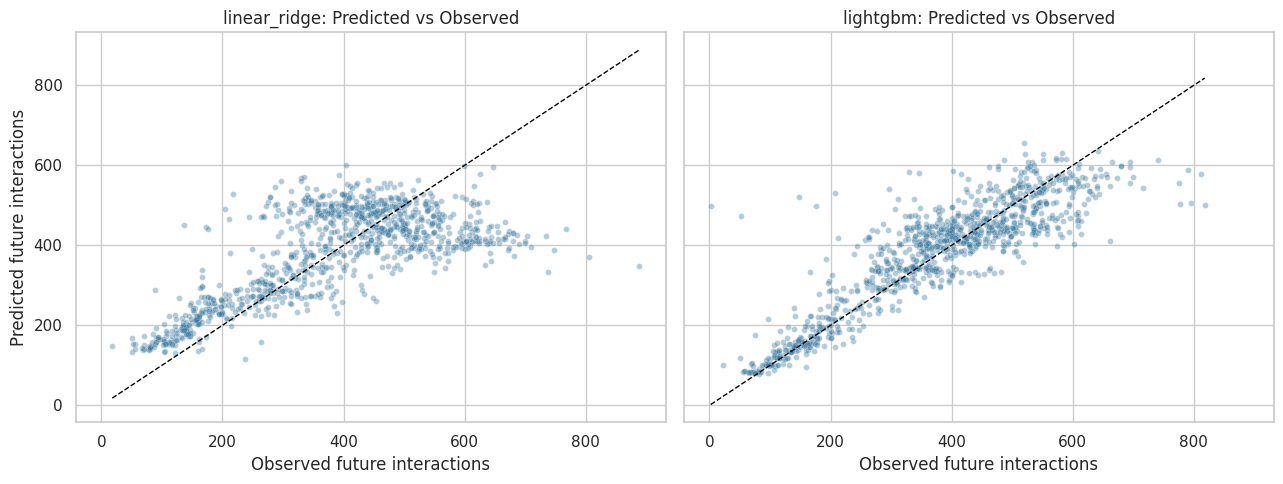

In [9]:
plot_scored = gcomp_scored.sample(min(2_000, len(gcomp_scored)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, model_name in zip(axes, ["linear_ridge", "lightgbm"]):
    model_plot = plot_scored.query("model == @model_name")
    sns.scatterplot(
        data=model_plot,
        x=PRIMARY_OUTCOME,
        y="pred_observed",
        alpha=0.35,
        s=18,
        ax=ax,
        color="#2A6F97",
    )
    min_value = min(model_plot[PRIMARY_OUTCOME].min(), model_plot["pred_observed"].min())
    max_value = max(model_plot[PRIMARY_OUTCOME].max(), model_plot["pred_observed"].max())
    ax.plot([min_value, max_value], [min_value, max_value], color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{model_name}: Predicted vs Observed")
    ax.set_xlabel("Observed future interactions")
    ax.set_ylabel("Predicted future interactions")

plt.tight_layout()
plt.show()


The scatter plots show how well each model tracks observed future engagement. Large vertical spread is expected because future behavior is noisy, but the model should still capture meaningful variation rather than predicting one constant value for everyone.


## Calibration by Prediction Bin

Calibration checks whether rows with higher predicted outcomes actually have higher observed outcomes. This is a useful outcome-model diagnostic because g-computation relies on the level of predicted counterfactual outcomes.


In [10]:
def prediction_calibration_table(scored, n_bins=10):
    frames = []
    for model_name, model_data in scored.groupby("model"):
        temp = model_data.copy()
        temp["prediction_bin"] = pd.qcut(temp["pred_observed"], q=n_bins, duplicates="drop")
        frame = (
            temp.groupby("prediction_bin", observed=True)
            .agg(
                rows=(PRIMARY_OUTCOME, "size"),
                mean_predicted=("pred_observed", "mean"),
                mean_observed=(PRIMARY_OUTCOME, "mean"),
                mean_residual=("residual", "mean"),
            )
            .reset_index()
        )
        frame.insert(0, "model", model_name)
        frames.append(frame)
    return pd.concat(frames, ignore_index=True)

calibration = prediction_calibration_table(gcomp_scored)
display(calibration)


,model,prediction_bin,rows,mean_predicted,mean_observed,mean_residual
0,lightgbm,"(77.664, 156.969]",470,121.2450,118.3745,-2.8705
1,lightgbm,"(156.969, 243.43]",470,196.3886,195.4213,-0.9673
2,lightgbm,"(243.43, 331.146]",470,293.2714,294.3170,1.0457
3,lightgbm,"(331.146, 381.112]",469,350.9291,347.0362,-3.8928
4,lightgbm,"(381.112, 414.707]",470,400.0981,401.1340,1.0359
5,lightgbm,"(414.707, 438.505]",470,426.5840,427.0745,0.4904
6,lightgbm,"(438.505, 464.164]",469,450.2288,448.0874,-2.1413
7,lightgbm,"(464.164, 502.289]",470,480.6242,480.8106,0.1864
8,lightgbm,"(502.289, 548.924]",470,526.6655,536.8596,10.1940
9,lightgbm,"(548.924, 679.474]",470,577.2190,571.7766,-5.4424


The calibration table checks whether predicted outcome levels are systematically too high or too low across the prediction range. Good calibration makes the counterfactual averages easier to trust.


## Plot Outcome Calibration

The dashed diagonal represents perfect calibration. Points above the line mean observed future engagement is higher than predicted; points below the line mean the model overpredicts.


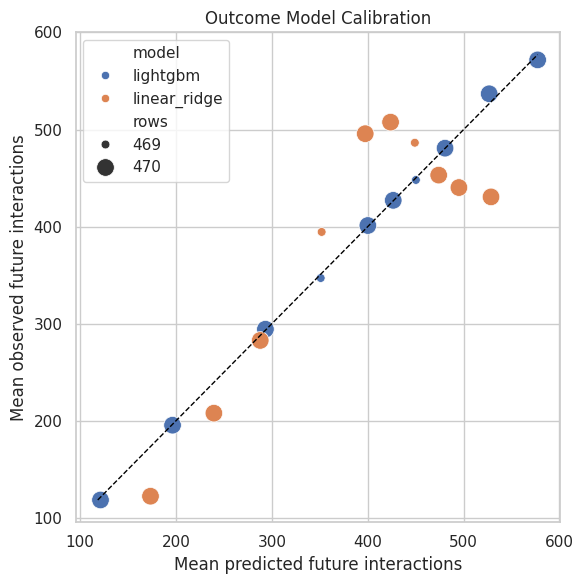

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(
    data=calibration,
    x="mean_predicted",
    y="mean_observed",
    hue="model",
    size="rows",
    sizes=(40, 160),
    ax=ax,
)
min_axis = min(calibration["mean_predicted"].min(), calibration["mean_observed"].min())
max_axis = max(calibration["mean_predicted"].max(), calibration["mean_observed"].max())
ax.plot([min_axis, max_axis], [min_axis, max_axis], color="black", linestyle="--", linewidth=1)
ax.set_title("Outcome Model Calibration")
ax.set_xlabel("Mean predicted future interactions")
ax.set_ylabel("Mean observed future interactions")
plt.tight_layout()
plt.show()


The calibration plot turns model quality into a visual check. If the flexible model calibrates better than the linear model, its counterfactual estimates may be more credible, though they still need sensitivity checks.


## Estimate G-Computation Effects

The g-computation estimate is the average predicted outcome under treatment minus the average predicted outcome under control. This cell summarizes both the average treatment effect and the distribution of row-level predicted effects.


In [12]:
gcomp_results = (
    gcomp_scored.groupby("model")
    .agg(
        n_rows=(PRIMARY_OUTCOME, "size"),
        observed_outcome_mean=(PRIMARY_OUTCOME, "mean"),
        mean_pred_observed=("pred_observed", "mean"),
        mean_y1_hat=("pred_y1", "mean"),
        mean_y0_hat=("pred_y0", "mean"),
        ate=("cate_hat", "mean"),
        cate_std=("cate_hat", "std"),
        cate_p05=("cate_hat", lambda values: values.quantile(0.05)),
        cate_median=("cate_hat", "median"),
        cate_p95=("cate_hat", lambda values: values.quantile(0.95)),
        share_positive_cate=("cate_hat", lambda values: (values > 0).mean()),
    )
    .reset_index()
)

gcomp_results["relative_lift_vs_y0"] = gcomp_results["ate"] / gcomp_results["mean_y0_hat"]

display(gcomp_results)


,model,n_rows,observed_outcome_mean,mean_pred_observed,mean_y1_hat,mean_y0_hat,ate,cate_std,cate_p05,cate_median,cate_p95,share_positive_cate,relative_lift_vs_y0
0,lightgbm,4698,382.0826,382.3176,382.3398,382.3040,0.0359,0.7680,-0.9658,0.0000,1.0999,0.1249,0.0001
1,linear_ridge,4698,382.0826,382.0539,383.2312,380.9024,2.3288,2.4159,-1.8905,2.3053,5.3646,0.8012,0.0061


This is the main g-computation result table. The `ate` column estimates the average causal effect implied by each outcome model, while the CATE distribution columns show whether the model predicts similar or heterogeneous effects across user-days.


## Plot Counterfactual Means

This plot compares the model-implied average outcome under treatment and under control. It is often easier to communicate g-computation this way: the model predicts two potential outcome means, and their gap is the estimated effect.


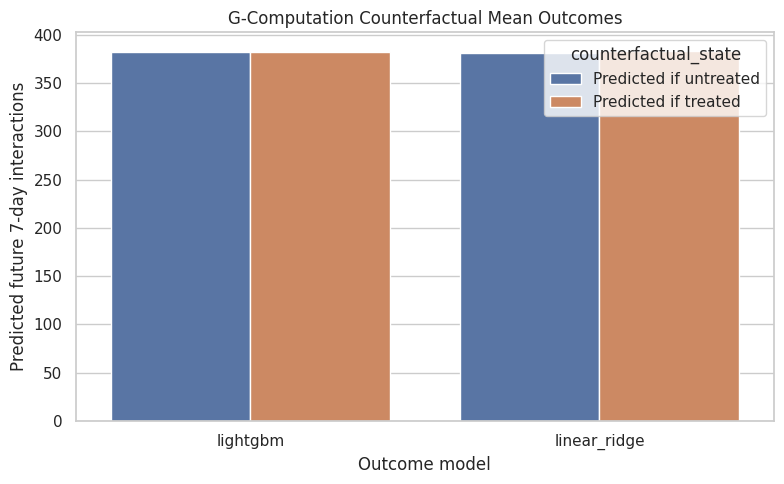

In [13]:
cf_means_plot = gcomp_results.melt(
    id_vars="model",
    value_vars=["mean_y0_hat", "mean_y1_hat"],
    var_name="counterfactual_state",
    value_name="predicted_mean_outcome",
)
cf_means_plot["counterfactual_state"] = cf_means_plot["counterfactual_state"].map(
    {"mean_y0_hat": "Predicted if untreated", "mean_y1_hat": "Predicted if treated"}
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=cf_means_plot,
    x="model",
    y="predicted_mean_outcome",
    hue="counterfactual_state",
    ax=ax,
)
ax.set_title("G-Computation Counterfactual Mean Outcomes")
ax.set_xlabel("Outcome model")
ax.set_ylabel("Predicted future 7-day interactions")
plt.tight_layout()
plt.show()


The counterfactual mean plot shows the estimated potential outcome gap directly. If the treated and untreated bars are close, the model is saying high-watch exposure has little average effect on future interaction volume.


## Plot Row-Level Predicted Effects

The row-level `cate_hat` values are not experimental individual treatment effects, but they show how the outcome model expects treatment effects to vary across observed histories. LightGBM can produce heterogeneous effects; the additive linear model may produce a nearly constant effect.


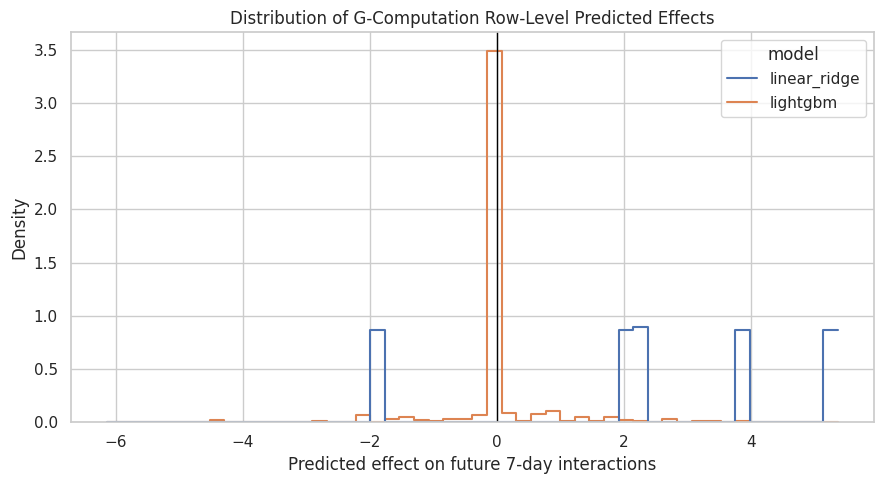

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(
    data=gcomp_scored,
    x="cate_hat",
    hue="model",
    bins=50,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    ax=ax,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Distribution of G-Computation Row-Level Predicted Effects")
ax.set_xlabel("Predicted effect on future 7-day interactions")
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()


The CATE-style distribution helps distinguish a global average effect from heterogeneity. If LightGBM shows a wide distribution, the next project step could inspect which user histories are associated with larger positive or negative predicted effects.


## Segment-Level G-Computation Effects

This cell summarizes predicted effects across simple history segments. Segment summaries are not the primary estimand, but they help explain whether the average effect is hiding important variation by prior engagement level.


In [15]:
segment_panel = panel[["user_id", "event_date", "prior_3day_interactions", "prior_3day_high_watch_share"]].copy()
segment_panel["prior_interactions_bucket"] = pd.qcut(
    segment_panel["prior_3day_interactions"],
    q=4,
    duplicates="drop",
)
segment_panel["prior_high_watch_bucket"] = pd.qcut(
    segment_panel["prior_3day_high_watch_share"],
    q=4,
    duplicates="drop",
)

segmented_scored = gcomp_scored.merge(
    segment_panel[["user_id", "event_date", "prior_interactions_bucket", "prior_high_watch_bucket"]],
    on=["user_id", "event_date"],
    how="left",
)

segment_effects = []
for segment_col in ["prior_interactions_bucket", "prior_high_watch_bucket"]:
    summary = (
        segmented_scored.groupby(["model", segment_col], observed=True)
        .agg(
            rows=("cate_hat", "size"),
            ate=("cate_hat", "mean"),
            cate_std=("cate_hat", "std"),
            observed_outcome_mean=(PRIMARY_OUTCOME, "mean"),
        )
        .reset_index()
        .rename(columns={segment_col: "segment"})
    )
    summary.insert(1, "segment_type", segment_col)
    segment_effects.append(summary)

segment_gcomp_effects = pd.concat(segment_effects, ignore_index=True)
display(segment_gcomp_effects)


,model,segment_type,segment,rows,ate,cate_std,observed_outcome_mean
0,lightgbm,prior_interactions_bucket,"(-0.001, 123.0]",1183,-0.0428,0.4879,276.2113
1,lightgbm,prior_interactions_bucket,"(123.0, 166.0]",1182,0.0062,0.5888,386.9205
2,lightgbm,prior_interactions_bucket,"(166.0, 217.0]",1164,0.0244,0.7948,420.7345
3,lightgbm,prior_interactions_bucket,"(217.0, 581.0]",1169,0.1569,1.0627,445.8435
4,linear_ridge,prior_interactions_bucket,"(-0.001, 123.0]",1183,2.1703,2.4964,276.2113
5,linear_ridge,prior_interactions_bucket,"(123.0, 166.0]",1182,2.4662,2.3430,386.9205
6,linear_ridge,prior_interactions_bucket,"(166.0, 217.0]",1164,2.3710,2.3921,420.7345
7,linear_ridge,prior_interactions_bucket,"(217.0, 581.0]",1169,2.3081,2.4225,445.8435
8,lightgbm,prior_high_watch_bucket,"(-0.001, 1.127]",1175,0.0551,0.6319,368.0732
9,lightgbm,prior_high_watch_bucket,"(1.127, 1.414]",1174,0.1259,0.9780,386.3526


The segment table shows where the outcome model predicts stronger or weaker effects. These are exploratory heterogeneity diagnostics, useful for interpretation but not a replacement for the primary average treatment effect.


## User-Cluster Bootstrap for G-Computation

The analysis has repeated user-days, so bootstrap uncertainty should resample users rather than individual rows. This cell refits each outcome model on user-cluster bootstrap samples and recomputes the g-computation estimate.

The bootstrap is intentionally moderate in size to keep the notebook runnable while still giving a useful uncertainty check.


In [16]:
def fit_predict_gcomp_effect(model, data, feature_cols, outcome_col):
    X = data[feature_cols].copy()
    y = data[outcome_col].astype(float)
    fitted_model = clone(model).fit(X, y)
    pred_y1 = fitted_model.predict(make_counterfactual_features(X, 1))
    pred_y0 = fitted_model.predict(make_counterfactual_features(X, 0))
    return float(np.mean(pred_y1 - pred_y0))

N_BOOTSTRAP = 150
rng = np.random.default_rng(RANDOM_STATE)
user_ids = panel["user_id"].unique()
user_groups = {user_id: group.copy() for user_id, group in panel.groupby("user_id", sort=False)}

bootstrap_rows = []
for model_name, model in outcome_models.items():
    for bootstrap_id in range(N_BOOTSTRAP):
        sampled_users = rng.choice(user_ids, size=len(user_ids), replace=True)
        bootstrap_sample = pd.concat(
            [user_groups[user_id] for user_id in sampled_users],
            ignore_index=True,
        )
        effect = fit_predict_gcomp_effect(
            model,
            bootstrap_sample,
            outcome_features,
            PRIMARY_OUTCOME,
        )
        bootstrap_rows.append(
            {
                "model": model_name,
                "bootstrap_id": bootstrap_id,
                "ate": effect,
            }
        )

gcomp_bootstrap = pd.DataFrame(bootstrap_rows)

gcomp_bootstrap_summary = (
    gcomp_bootstrap.groupby("model")
    .agg(
        bootstrap_reps=("ate", "size"),
        bootstrap_mean=("ate", "mean"),
        bootstrap_std=("ate", "std"),
        ci_95_lower=("ate", lambda values: values.quantile(0.025)),
        ci_95_upper=("ate", lambda values: values.quantile(0.975)),
    )
    .reset_index()
)

display(gcomp_bootstrap_summary)


,model,bootstrap_reps,bootstrap_mean,bootstrap_std,ci_95_lower,ci_95_upper
0,lightgbm,150,0.1756,0.6123,-0.6384,1.8656
1,linear_ridge,150,1.3476,4.3325,-6.3238,9.3565


The bootstrap summary adds uncertainty to the g-computation estimates while respecting user clustering. Wide intervals mean the outcome-model estimate should be treated cautiously even if the point estimate looks meaningful.


## Plot G-Computation Bootstrap Distributions

The bootstrap distributions show how much each model's estimated effect changes when users are resampled. This gives a visual uncertainty check alongside the numeric confidence intervals.


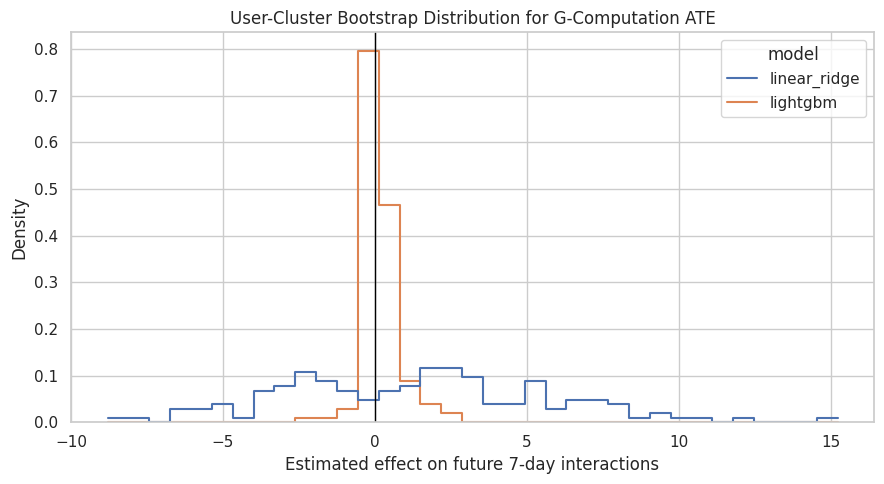

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(
    data=gcomp_bootstrap,
    x="ate",
    hue="model",
    bins=35,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    ax=ax,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("User-Cluster Bootstrap Distribution for G-Computation ATE")
ax.set_xlabel("Estimated effect on future 7-day interactions")
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()


The bootstrap plot shows whether the g-computation effect is consistently positive, consistently negative, or uncertain around zero. This will be important when comparing against the MSM result.


## Compare G-Computation with the MSM Estimate

This cell loads the primary MSM effect from Notebook 04 and places it next to the g-computation estimates. This is the main cross-method comparison for the project.


In [18]:
msm_primary = pd.read_csv(MSM_PRIMARY_PATH)
msm_lookup = dict(zip(msm_primary["quantity"], msm_primary["value"]))

msm_comparison_row = {
    "method": "MSM: weighted calendar-adjusted",
    "model": "propensity_weighted_msm",
    "estimate": msm_lookup["estimated_incremental_future_7day_interactions"],
    "ci_95_lower": msm_lookup["bootstrap_ci_lower"],
    "ci_95_upper": msm_lookup["bootstrap_ci_upper"],
    "source": "Notebook 04 user-cluster bootstrap",
}

gcomp_comparison_rows = []
for _, row in gcomp_results.iterrows():
    boot_row = gcomp_bootstrap_summary.query("model == @row.model").iloc[0]
    gcomp_comparison_rows.append(
        {
            "method": "G-computation",
            "model": row["model"],
            "estimate": row["ate"],
            "ci_95_lower": boot_row["ci_95_lower"],
            "ci_95_upper": boot_row["ci_95_upper"],
            "source": "Notebook 05 user-cluster bootstrap",
        }
    )

estimator_comparison = pd.DataFrame([msm_comparison_row, *gcomp_comparison_rows])
estimator_comparison["relative_lift_vs_msm_control_mean"] = (
    estimator_comparison["estimate"] / msm_lookup["weighted_control_mean_future_7day_interactions"]
)

display(estimator_comparison)


,method,model,estimate,ci_95_lower,ci_95_upper,source,relative_lift_vs_msm_control_mean
0,MSM: weighted calendar-adjusted,propensity_weighted_msm,-2.6877,-12.2706,5.7291,Notebook 04 user-cluster bootstrap,-0.0072
1,G-computation,lightgbm,0.0359,-0.6384,1.8656,Notebook 05 user-cluster bootstrap,0.0001
2,G-computation,linear_ridge,2.3288,-6.3238,9.3565,Notebook 05 user-cluster bootstrap,0.0062


The comparison table is the key conclusion check. If MSM and g-computation estimates are close and uncertain around zero, that supports an honest conclusion: the observed data does not show a clear long-term interaction-volume effect from high-watch exposure.


## Plot Cross-Estimator Comparison

This plot compares the MSM estimate and the g-computation estimates on the same outcome scale. The intervals come from user-cluster bootstrap procedures in Notebooks 04 and 05.


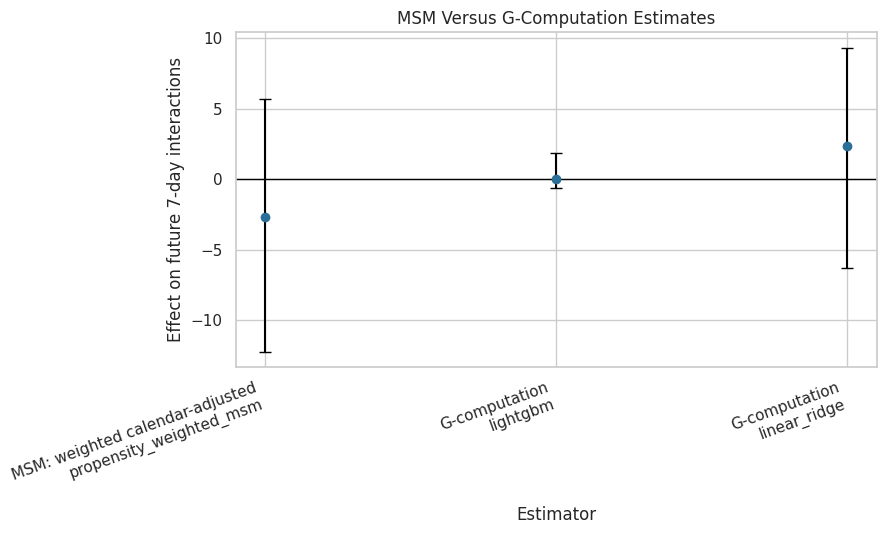

In [19]:
plot_comparison = estimator_comparison.copy()
plot_comparison["label"] = plot_comparison["method"] + "\n" + plot_comparison["model"]
plot_comparison["lower_error"] = plot_comparison["estimate"] - plot_comparison["ci_95_lower"]
plot_comparison["upper_error"] = plot_comparison["ci_95_upper"] - plot_comparison["estimate"]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.errorbar(
    x=np.arange(len(plot_comparison)),
    y=plot_comparison["estimate"],
    yerr=[plot_comparison["lower_error"], plot_comparison["upper_error"]],
    fmt="o",
    color="#2A6F97",
    ecolor="black",
    capsize=4,
)
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(np.arange(len(plot_comparison)))
ax.set_xticklabels(plot_comparison["label"], rotation=20, ha="right")
ax.set_title("MSM Versus G-Computation Estimates")
ax.set_ylabel("Effect on future 7-day interactions")
ax.set_xlabel("Estimator")
plt.tight_layout()
plt.show()


The plot makes estimator agreement or disagreement easy to see. Cross-method consistency is more persuasive than any single estimate, especially in an observational sequential recommender log.


## Secondary Outcome G-Computation

The primary outcome is future 7-day interaction volume. This cell repeats g-computation with the LightGBM outcome model for secondary outcomes, so we can see whether the story changes for active days or watch hours.


In [20]:
secondary_outcomes = [
    "future_7day_active_days",
    "future_7day_avg_daily_interactions",
    "future_7day_play_hours",
    "outcome_log1p",
]

secondary_rows = []
secondary_model = outcome_models["lightgbm"]
for outcome_col in secondary_outcomes:
    scored_secondary, metrics_secondary = cross_fitted_gcomp(
        secondary_model,
        panel,
        outcome_features,
        outcome_col,
        groups,
        model_name=f"lightgbm_{outcome_col}",
        n_splits=5,
    )
    secondary_rows.append(
        {
            "outcome": outcome_col,
            "model": "lightgbm",
            "ate": scored_secondary["cate_hat"].mean(),
            "mean_y1_hat": scored_secondary["pred_y1"].mean(),
            "mean_y0_hat": scored_secondary["pred_y0"].mean(),
            "relative_lift_vs_y0": scored_secondary["cate_hat"].mean() / scored_secondary["pred_y0"].mean(),
            "rmse_mean": metrics_secondary["rmse"].mean(),
            "mae_mean": metrics_secondary["mae"].mean(),
            "r2_mean": metrics_secondary["r2"].mean(),
        }
    )

secondary_gcomp_results = pd.DataFrame(secondary_rows)
display(secondary_gcomp_results)


,outcome,model,ate,mean_y1_hat,mean_y0_hat,relative_lift_vs_y0,rmse_mean,mae_mean,r2_mean
0,future_7day_active_days,lightgbm,-0.0176,6.8424,6.8601,-0.0026,0.5294,0.2543,-0.0250
1,future_7day_avg_daily_interactions,lightgbm,0.0051,54.6200,54.6149,0.0001,10.2085,7.4032,0.7905
2,future_7day_play_hours,lightgbm,0.0396,0.9374,0.8978,0.0441,0.2349,0.1654,0.6964
3,outcome_log1p,lightgbm,0.0003,5.8347,5.8344,0.0001,0.2169,0.1426,0.8291


The secondary outcome table checks whether the g-computation conclusion is specific to interaction volume or appears in other long-term behavior measures. Differences across outcomes should be reported as part of the product interpretation.


## Save G-Computation Results

This cell saves the main g-computation estimates, model diagnostics, counterfactual predictions, bootstrap results, estimator comparison, segment summaries, and secondary outcome estimates.


In [21]:
gcomp_results_path = PROCESSED_DIR / "kuairec_long_term_gcomp_results.csv"
gcomp_metrics_path = PROCESSED_DIR / "kuairec_long_term_gcomp_model_metrics.csv"
gcomp_counterfactuals_path = PROCESSED_DIR / "kuairec_long_term_gcomp_counterfactuals.parquet"
gcomp_bootstrap_path = PROCESSED_DIR / "kuairec_long_term_gcomp_bootstrap.csv"
gcomp_bootstrap_summary_path = PROCESSED_DIR / "kuairec_long_term_gcomp_bootstrap_summary.csv"
estimator_comparison_path = PROCESSED_DIR / "kuairec_long_term_estimator_comparison.csv"
segment_gcomp_path = PROCESSED_DIR / "kuairec_long_term_gcomp_segment_effects.csv"
secondary_gcomp_path = PROCESSED_DIR / "kuairec_long_term_gcomp_secondary_outcomes.csv"

# Keep one row per user-day/model with the counterfactual predictions needed for later reporting.
gcomp_counterfactuals = gcomp_scored[[
    "user_id",
    "event_date",
    "model",
    PRIMARY_TREATMENT,
    PRIMARY_OUTCOME,
    "pred_observed",
    "pred_y1",
    "pred_y0",
    "cate_hat",
    "residual",
]].copy()

gcomp_results.to_csv(gcomp_results_path, index=False)
outcome_model_metrics.to_csv(gcomp_metrics_path, index=False)
gcomp_counterfactuals.to_parquet(gcomp_counterfactuals_path, index=False)
gcomp_bootstrap.to_csv(gcomp_bootstrap_path, index=False)
gcomp_bootstrap_summary.to_csv(gcomp_bootstrap_summary_path, index=False)
estimator_comparison.to_csv(estimator_comparison_path, index=False)
segment_gcomp_effects.to_csv(segment_gcomp_path, index=False)
secondary_gcomp_results.to_csv(secondary_gcomp_path, index=False)

print("Saved Notebook 05 artifacts:")
print(f"- {gcomp_results_path}")
print(f"- {gcomp_metrics_path}")
print(f"- {gcomp_counterfactuals_path}")
print(f"- {gcomp_bootstrap_path}")
print(f"- {gcomp_bootstrap_summary_path}")
print(f"- {estimator_comparison_path}")
print(f"- {segment_gcomp_path}")
print(f"- {secondary_gcomp_path}")


Saved Notebook 05 artifacts:
- /home/apex/Documents/ranking_sys/data/processed/kuairec_long_term_gcomp_results.csv
- /home/apex/Documents/ranking_sys/data/processed/kuairec_long_term_gcomp_model_metrics.csv
- /home/apex/Documents/ranking_sys/data/processed/kuairec_long_term_gcomp_counterfactuals.parquet
- /home/apex/Documents/ranking_sys/data/processed/kuairec_long_term_gcomp_bootstrap.csv
- /home/apex/Documents/ranking_sys/data/processed/kuairec_long_term_gcomp_bootstrap_summary.csv
- /home/apex/Documents/ranking_sys/data/processed/kuairec_long_term_estimator_comparison.csv
- /home/apex/Documents/ranking_sys/data/processed/kuairec_long_term_gcomp_segment_effects.csv
- /home/apex/Documents/ranking_sys/data/processed/kuairec_long_term_gcomp_secondary_outcomes.csv


The g-computation artifacts are saved for the final project report. The most important files are the estimator comparison table and the counterfactual predictions, because they let the next notebook summarize cross-method agreement and heterogeneity.


## Takeaways and Next Step

This notebook estimated the primary long-term effect using g-computation. It modeled future engagement directly, generated counterfactual predictions under treatment and control, summarized average and row-level predicted effects, and compared those estimates with the MSM result from Notebook 04.

The key value of this notebook is cross-method triangulation. If the MSM and g-computation estimates both suggest a small or uncertain effect on future 7-day interactions, then the final project should say that clearly rather than forcing a positive story.

The next notebook should be the final sensitivity and report notebook. It should combine the MSM and g-computation outputs, state the final conclusion, document limitations, and create portfolio-ready tables/figures.
